## Import and Data

In [2]:
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt

In [3]:
# Unit Values

forward_unit_values_df = pd.read_csv('Daily Valuations/forward_unit_daily_values_all_data.csv',
                                           parse_dates=['Pricing_Date', 'Start_Date', 'Settlement_Date', 'Exit_Date', 'Expiry_Date', 'Delivery_Date'],
                                           dayfirst=True)

rr45_unit_values_df = pd.read_csv('Daily Valuations/rr45_unit_daily_values.csv',
                                           parse_dates=['Pricing_Date', 'Start_Date', 'Settlement_Date', 'Exit_Date', 'Expiry_Date', 'Delivery_Date'])

unhedged_values_df = pd.read_csv('Daily Valuations/unhedged_unit_daily_values.csv',
                                           parse_dates=['Pricing_Date'])

# Pre set hedges

forward_spot_hedge_values_df = pd.read_csv('Daily Valuations/forward_spot_hedge_notional_daily_values (1).csv',
                                           parse_dates=['Pricing_Date', 'Start_Date', 'Settlement_Date', 'Exit_Date', 'Expiry_Date', 'Delivery_Date'])

rr45_spot_hedge_values_df = pd.read_csv('Daily Valuations/rr45_spot_hedge_notional_daily_values (1).csv',
                                           parse_dates=['Pricing_Date', 'Start_Date', 'Settlement_Date', 'Exit_Date', 'Expiry_Date', 'Delivery_Date'])

rr45_delta_hedge_values_df = pd.read_csv('Daily Valuations/rr45_delta_hedge_notional_daily_values (1).csv',
                                           parse_dates=['Pricing_Date', 'Start_Date', 'Settlement_Date', 'Exit_Date', 'Expiry_Date', 'Delivery_Date'])


### Contract Dates for reference

In [4]:
first_contract_start = rr45_delta_hedge_values_df['Start_Date'][0]
last_contract_start = rr45_delta_hedge_values_df.iloc[-1]['Start_Date']


first_contract_exit = rr45_delta_hedge_values_df['Exit_Date'][0]
last_contract_exit = rr45_delta_hedge_values_df.iloc[-1]['Exit_Date']

first_pricing_date = rr45_delta_hedge_values_df['Pricing_Date'][0]
last_pricing_date = rr45_delta_hedge_values_df.iloc[-1]['Pricing_Date']

print(first_contract_start)
print(first_contract_exit)
print(first_pricing_date)
print(last_contract_start)
print(last_contract_exit)
print(last_pricing_date)

2021-04-14 00:00:00
2021-05-03 00:00:00
2021-04-14 00:00:00
2026-04-06 00:00:00
2026-07-06 00:00:00
2026-04-14 00:00:00


## Add Marked to Market Column: forward and risk reversal

In [5]:
# forward and rr df have these columns in common:
# Contract_ID  Position  Pricing_Date  Start_Date  Settlement_Date  Expiry_Date  Delivery_Date  Exit_Date  Value  Notional  Value (Notional)

# unhedged df has these columns:
# Pricing_Date  Initial_Spot  Initial_CNH_Amount  Current_Spot  USDCNH_Exposure

pricing_dates = pd.date_range(start=first_pricing_date, end=last_pricing_date, freq="D")

portfolios_fd_rr = [
    forward_unit_values_df,
    forward_spot_hedge_values_df,
    rr45_delta_hedge_values_df,
    rr45_spot_hedge_values_df,
    rr45_unit_values_df,
]

# Get marked to market for each contract
for portfolio in portfolios_fd_rr:
    portfolio["Contract MTM"] = 0.0
    for contract in portfolio["Contract_ID"].unique():
        mask = portfolio["Contract_ID"] == contract
        contract_idx = portfolio[mask].index
        for i, idx in enumerate(contract_idx):
            if portfolio.loc[idx, "Pricing_Date"] == portfolio.loc[idx, "Start_Date"]:
                portfolio.loc[idx, "Contract MTM"] = 0
            else:
                portfolio.loc[idx, "Contract MTM"] = (
                    portfolio.loc[idx, "Value (Notional)"]
                    - portfolio.loc[contract_idx[i - 1], "Value (Notional)"]
                )

# Error check - mtm sum == exit value
for portfolio in portfolios_fd_rr:
    for contract in portfolio["Contract_ID"].unique():
        contract_data = portfolio[portfolio["Contract_ID"] == contract]
        mtm_sum = contract_data["Contract MTM"].sum()
        exit_value = contract_data[
            contract_data["Pricing_Date"] == contract_data["Exit_Date"]
        ]["Value (Notional)"].values
        if len(exit_value) > 0 and abs(mtm_sum - exit_value[0]) > 1e-6:
            print(
                f"Contract {contract} failed: MTM sum = {mtm_sum}, Exit value = {exit_value[0]}"
            )

# Error check - mtm sum == last row value
for portfolio in portfolios_fd_rr:
    for contract in portfolio["Contract_ID"].unique():
        contract_data = portfolio[portfolio["Contract_ID"] == contract]
        mtm_sum = contract_data["Contract MTM"].sum()
        exit_value = contract_data.iloc[-1]["Value (Notional)"]
        if abs(mtm_sum - exit_value) > 1e-6:
            print(
                f"Contract {contract} failed: MTM sum = {mtm_sum}, Exit value = {exit_value}"
            )

## Create position pnl dataframes: forward and risk reversal

In [6]:
# Build a daily active-contract dataframe for each forward portfolio
# Columns: Active_Contract, Position, Pricing_Date, Contracted_Forward, Market_Forward, Value, Notional, Value (Notional), Contract MTM

forward_portfolios = [forward_unit_values_df, forward_spot_hedge_values_df]

new_forward_portfolio_dfs = []
for p_idx, portfolio in enumerate(forward_portfolios):
    rows = []
    for position in portfolio['Position'].unique():
        mask = portfolio['Position'] == position
        position_idx = list(portfolio[mask].index)
        j = 0
        while j < len(position_idx):
            idx = position_idx[j]
            this_row = portfolio.loc[idx]
            next_row = None
            if j + 1 < len(position_idx):
                next_row = portfolio.loc[position_idx[j + 1]]

            if next_row is not None and pd.notna(next_row['Pricing_Date']) and next_row['Pricing_Date'] == this_row['Pricing_Date']:
                # this row is the exit of the previous contract; next_row is the new active contract
                rows.append({
                    'Active_Contract': next_row['Contract_ID'],
                    'Position': position,
                    'Pricing_Date': this_row['Pricing_Date'],
                    'Contracted_Forward': next_row['Contracted_Forward'],
                    'Market_Forward': next_row['Market_Forward'],
                    # 'Implied_Domestic_Rate': next_row['Implied_Domestic_Rate'],
                    # 'Time_Discount_Domestic': next_row['Time_Discount_Domestic'],
                    'Value': next_row['Value'],
                    'Notional': next_row['Notional'],
                    'Value (Notional)': next_row['Value (Notional)'],
                    'Contract_MTM': this_row['Contract MTM'],
                    'Realised_PnL': this_row['Value (Notional)'],
                })
                j += 2
            else:
                rows.append({
                    'Active_Contract': this_row['Contract_ID'],
                    'Position': position,
                    'Pricing_Date': this_row['Pricing_Date'],
                    'Contracted_Forward': this_row['Contracted_Forward'],
                    'Market_Forward': this_row['Market_Forward'],
                    # 'Implied_Domestic_Rate': this_row['Implied_Domestic_Rate'],
                    # 'Time_Discount_Domestic': this_row['Time_Discount_Domestic'],
                    'Value': this_row['Value'],
                    'Notional': this_row['Notional'],
                    'Value (Notional)': this_row['Value (Notional)'],
                    'Contract_MTM': this_row['Contract MTM'],
                    'Realised_PnL': 0,
                })
                j += 1

    portfolio_df = pd.DataFrame(rows)
    portfolio_df['Cumulative_PnL'] = (
        portfolio_df.groupby('Position')['Contract_MTM']
        .cumsum()
    )
    new_forward_portfolio_dfs.append(portfolio_df)

In [7]:
# Build a daily active-contract dataframe for each rr45 portfolio
# Columns: Active_Contract, Position, Pricing_Date, Call_Strike, Call_Vol, Call_Delta, Call_Premium,
#          Put_Strike, Put_Vol, Put_Delta, Put_Premium, Contract_Delta, Value, Notional,
#          Value (Notional), Delta_Notional, Value (Delta_Notional), Contract MTM

rr45_portfolios = [rr45_delta_hedge_values_df, rr45_spot_hedge_values_df, rr45_unit_values_df]

new_rr45_portfolio_dfs = []
for p_idx, portfolio in enumerate(rr45_portfolios):
    rows = []
    for position in portfolio['Position'].unique():
        mask = portfolio['Position'] == position
        position_idx = list(portfolio[mask].index)
        j = 0
        while j < len(position_idx):
            idx = position_idx[j]
            this_row = portfolio.loc[idx]
            next_row = None
            if j + 1 < len(position_idx):
                next_row = portfolio.loc[position_idx[j + 1]]

            if next_row is not None and pd.notna(next_row['Pricing_Date']) and next_row['Pricing_Date'] == this_row['Pricing_Date']:
                # this row is the exit of the previous contract; next_row is the new active contract
                rows.append({
                    'Active_Contract': next_row['Contract_ID'],
                    'Position': position,
                    'Pricing_Date': this_row['Pricing_Date'],
                    'Call_Strike': next_row['Call_Strike'],
                    'Call_Vol': next_row['Call_Vol'],
                    'Call_Delta': next_row['Call_Delta'],
                    'Call_Premium': next_row['Call_Premium'],
                    'Put_Strike': next_row['Put_Strike'],
                    'Put_Vol': next_row['Put_Vol'],
                    'Put_Delta': next_row['Put_Delta'],
                    'Put_Premium': next_row['Put_Premium'],
                    'Contract_Delta': next_row['Contract_Delta'],
                    'Value': next_row['Value'],
                    'Notional': next_row['Notional'],
                    'Value (Notional)': next_row['Value (Notional)'],
                    'Delta_Notional': next_row['Delta_Notional'],
                    'Value (Delta_Notional)': next_row['Value (Delta_Notional)'],
                    'Contract_MTM': this_row['Contract MTM'], # contract exited that day contributes to mtm
                    'Realised_PnL': this_row['Value (Notional)'] # contract exited that day, realised the value
                })
                j += 2  # skip next row as it's been consumed
            else:
                rows.append({
                    'Active_Contract': this_row['Contract_ID'],
                    'Position': position,
                    'Pricing_Date': this_row['Pricing_Date'],
                    'Call_Strike': this_row['Call_Strike'],
                    'Call_Vol': this_row['Call_Vol'],
                    'Call_Delta': this_row['Call_Delta'],
                    'Call_Premium': this_row['Call_Premium'],
                    'Put_Strike': this_row['Put_Strike'],
                    'Put_Vol': this_row['Put_Vol'],
                    'Put_Delta': this_row['Put_Delta'],
                    'Put_Premium': this_row['Put_Premium'],
                    'Contract_Delta': this_row['Contract_Delta'],
                    'Value': this_row['Value'],
                    'Notional': this_row['Notional'],
                    'Value (Notional)': this_row['Value (Notional)'],
                    'Delta_Notional': this_row['Delta_Notional'],
                    'Value (Delta_Notional)': this_row['Value (Delta_Notional)'],
                    'Contract_MTM': this_row['Contract MTM'],
                    'Realised_PnL': 0, # no realised P&L on this day since we haven't exited the contract
                })
                j += 1
    
    portfolio_df = pd.DataFrame(rows)
    portfolio_df['Cumulative_PnL'] = (
        portfolio_df.groupby('Position')['Contract_MTM']
        .cumsum()
    )
    new_rr45_portfolio_dfs.append(portfolio_df)

### Save position pnl dataframes: forward and risk reversal

In [8]:
forward_unit_fixed_position_pnl_df, forward_spot_hedge_position_pnl_df = new_forward_portfolio_dfs

rr45_delta_hedge_position_pnl_df, rr45_spot_hedge_position_pnl_df, rr45_unit_fixed_position_pnl_df = new_rr45_portfolio_dfs

In [9]:
forward_unit_fixed_position_pnl_df.to_csv('Profit and Loss/forward_unit_position_pnl.csv', index=False)
forward_spot_hedge_position_pnl_df.to_csv('Profit and Loss/forward_spot_hedge_position_pnl.csv', index=False)

rr45_delta_hedge_position_pnl_df.to_csv('Profit and Loss/rr45_delta_hedge_position_pnl.csv', index=False)
rr45_spot_hedge_position_pnl_df.to_csv('Profit and Loss/rr45_spot_hedge_position_pnl.csv', index=False)
rr45_unit_fixed_position_pnl_df.to_csv('Profit and Loss/rr45_unit_position_pnl.csv', index=False)

## Create complete pnls

In [10]:
def build_portfolio_complete_pnl(portfolio_df, is_rr45=False):
    
    pricing_dates = portfolio_df['Pricing_Date'].unique()
    positions = sorted(portfolio_df['Position'].unique())

    rows = []
    for date in pricing_dates:
        day_data = portfolio_df[portfolio_df['Pricing_Date'] == date]

        row = {'Pricing_Date': date}

        # Active contract per position (up to 3 positions)
        for i, pos in enumerate(positions[:3], start=1):
            pos_data = day_data[day_data['Position'] == pos]
            row[f'Position{i}_Active_Contract'] = pos_data['Active_Contract'].values[0] if len(pos_data) > 0 else None

        # Portfolio-level aggregations
        row['Portfolio_Notional'] = day_data['Notional'].sum()
        row['Portfolio_Value (Notional)'] = day_data['Value (Notional)'].sum()
        row['Portfolio_MTM'] = day_data['Contract_MTM'].sum()
        row['Portfolio_Realised_PnL'] = day_data['Realised_PnL'].sum()
        row['Portfolio_Cumulative_PnL'] = day_data['Cumulative_PnL'].sum()

        # rr45-specific columns
        if is_rr45:
            row['Portfolio_Delta'] = day_data['Contract_Delta'].sum()
            row['Portfolio_Delta_Notional'] = day_data['Delta_Notional'].sum()
            row['Portfolio_Value (Delta_Notional)'] = day_data['Value (Delta_Notional)'].sum()

        rows.append(row)

    complete_pnl_df = pd.DataFrame(rows).sort_values('Pricing_Date').reset_index(drop=True)
    return complete_pnl_df


# Forward portfolios
forward_unit_fixed_complete_pnl_df = build_portfolio_complete_pnl(forward_unit_fixed_position_pnl_df, is_rr45=False)
forward_spot_hedge_complete_pnl_df = build_portfolio_complete_pnl(forward_spot_hedge_position_pnl_df, is_rr45=False)

# RR45 portfolios
rr45_delta_hedge_complete_pnl_df = build_portfolio_complete_pnl(rr45_delta_hedge_position_pnl_df, is_rr45=True)
rr45_spot_hedge_complete_pnl_df = build_portfolio_complete_pnl(rr45_spot_hedge_position_pnl_df, is_rr45=True)
rr45_unit_fixed_complete_pnl_df = build_portfolio_complete_pnl(rr45_unit_fixed_position_pnl_df, is_rr45=True)

In [11]:
unhedged_df = unhedged_values_df.sort_values('Pricing_Date').reset_index(drop=True)

unhedged_complete_pnl_df = pd.DataFrame({
    'Pricing_Date':                 unhedged_df['Pricing_Date'],
    'Position1_Active_Contract':    None,
    'Position2_Active_Contract':    None,
    'Position3_Active_Contract':    None,
    'Portfolio_Notional':           unhedged_df['USDCNH_Exposure'],
    'Portfolio_Value (Notional)':   unhedged_df['USDCNH_Exposure'],
    'Portfolio_MTM':                unhedged_df['USDCNH_Exposure'].diff().fillna(0),
    'Portfolio_Realised_PnL':       0,
    'Portfolio_Cumulative_PnL':     unhedged_df['USDCNH_Exposure'] - unhedged_df['USDCNH_Exposure'].iloc[0],
}).reset_index(drop=True)



### Filling missing dates: forward and risk reversal

In [12]:
def fill_missing_dates(df, is_rr45=False):

    df = df.copy()
    df['Pricing_Date'] = pd.to_datetime(df['Pricing_Date'])
    df = df.sort_values('Pricing_Date').reset_index(drop=True)

    # create a full calendar date range
    full_date_range = pd.date_range(start=df['Pricing_Date'].min(), end=df['Pricing_Date'].max(), freq='D')
    full_df = pd.DataFrame({'Pricing_Date': full_date_range})

    # merge to find missing dates
    merged_df = full_df.merge(df, on='Pricing_Date', how='left')

    # forward fill carry-over columns
    carry_forward_cols = [
        'Position1_Active_Contract',
        'Position2_Active_Contract',
        'Position3_Active_Contract',
        'Portfolio_Notional',
        'Portfolio_Value (Notional)',
        'Portfolio_Cumulative_PnL',
    ]
    if is_rr45:
        carry_forward_cols += [
            'Portfolio_Delta',
            'Portfolio_Delta_Notional',
            'Portfolio_Value (Delta_Notional)',
        ]

    merged_df[carry_forward_cols] = merged_df[carry_forward_cols].ffill()

    # fill zero columns
    zero_cols = ['Portfolio_MTM', 'Portfolio_Realised_PnL']
    merged_df[zero_cols] = merged_df[zero_cols].fillna(0)

    return merged_df.reset_index(drop=True)


# Forward portfolios
forward_unit_fixed_complete_pnl_df  = fill_missing_dates(forward_unit_fixed_complete_pnl_df,  is_rr45=False)
forward_spot_hedge_complete_pnl_df  = fill_missing_dates(forward_spot_hedge_complete_pnl_df,  is_rr45=False)

# RR45 portfolios
rr45_delta_hedge_complete_pnl_df    = fill_missing_dates(rr45_delta_hedge_complete_pnl_df,    is_rr45=True)
rr45_spot_hedge_complete_pnl_df     = fill_missing_dates(rr45_spot_hedge_complete_pnl_df,     is_rr45=True)
rr45_unit_fixed_complete_pnl_df     = fill_missing_dates(rr45_unit_fixed_complete_pnl_df,     is_rr45=True)

# Unhedged portfolio
unhedged_complete_pnl_df = fill_missing_dates(unhedged_complete_pnl_df, is_rr45=False)

### Save complete pnl csv: all

In [13]:
forward_unit_fixed_complete_pnl_df.to_csv('Profit and Loss/forward_unit_complete_pnl.csv', index=False)
forward_spot_hedge_complete_pnl_df.to_csv('Profit and Loss/forward_spot_hedge_complete_pnl.csv', index=False)

rr45_delta_hedge_complete_pnl_df.to_csv('Profit and Loss/rr45_delta_hedge_complete_pnl.csv', index=False)
rr45_spot_hedge_complete_pnl_df.to_csv('Profit and Loss/rr45_spot_hedge_complete_pnl.csv', index=False)
rr45_unit_fixed_complete_pnl_df.to_csv('Profit and Loss/rr45_unit_complete_pnl.csv', index=False)

unhedged_complete_pnl_df.to_csv('Profit and Loss/unhedged_complete_pnl.csv', index=False)

## Create hedged portfolios

In [14]:
def build_hedged_portfolio(hedge_df, unhedged_df, is_rr45=False):

    merged = hedge_df.merge(
        unhedged_df[['Pricing_Date', 'Portfolio_Notional', 'Portfolio_Value (Notional)', 
                     'Portfolio_MTM', 'Portfolio_Realised_PnL', 'Portfolio_Cumulative_PnL']],
        on='Pricing_Date',
        how='inner',
        suffixes=('_hedge', '_unhedged')
    )

    result = pd.DataFrame()

    # keep as-is from hedge df
    result['Pricing_Date']                  = merged['Pricing_Date']
    result['Position1_Active_Contract']     = merged['Position1_Active_Contract']
    result['Position2_Active_Contract']     = merged['Position2_Active_Contract']
    result['Position3_Active_Contract']     = merged['Position3_Active_Contract']

    # rename Portfolio -> Hedging (hedge df values unchanged)
    result['Hedging_Notional']              = merged['Portfolio_Notional_hedge']
    result['Hedging_Value (Notional)']      = merged['Portfolio_Value (Notional)_hedge']

    # rename Portfolio -> Physical (unhedged df values unchanged)
    result['Physical_Notional']             = merged['Portfolio_Notional_unhedged']

    # combined = hedge + unhedged
    result['Portfolio_MTM']                 = merged['Portfolio_MTM_hedge']             + merged['Portfolio_MTM_unhedged']
    result['Portfolio_Realised_PnL']        = merged['Portfolio_Realised_PnL_hedge']    + merged['Portfolio_Realised_PnL_unhedged']
    result['Portfolio_Cumulative_PnL']      = merged['Portfolio_Cumulative_PnL_hedge']  + merged['Portfolio_Cumulative_PnL_unhedged']

    if is_rr45:
        result['Portfolio_Delta']               = merged['Portfolio_Delta']
        result['Portfolio_Delta_Notional']      = merged['Portfolio_Delta_Notional']
        result['Portfolio_Value (Delta_Notional)'] = merged['Portfolio_Value (Delta_Notional)']

    return result.reset_index(drop=True)


# Forward hedged portfolios
forward_unit_fixed_hedged_df    = build_hedged_portfolio(forward_unit_fixed_complete_pnl_df,    unhedged_complete_pnl_df, is_rr45=False)
forward_spot_hedge_hedged_df    = build_hedged_portfolio(forward_spot_hedge_complete_pnl_df,    unhedged_complete_pnl_df, is_rr45=False)

# RR45 hedged portfolios
rr45_delta_hedge_hedged_df      = build_hedged_portfolio(rr45_delta_hedge_complete_pnl_df,      unhedged_complete_pnl_df, is_rr45=True)
rr45_spot_hedge_hedged_df       = build_hedged_portfolio(rr45_spot_hedge_complete_pnl_df,       unhedged_complete_pnl_df, is_rr45=True)
rr45_unit_fixed_hedged_df       = build_hedged_portfolio(rr45_unit_fixed_complete_pnl_df,       unhedged_complete_pnl_df, is_rr45=True)

### Save hedged csv

In [15]:
forward_unit_fixed_hedged_df.to_csv('Profit and Loss/hedged_forward_unit.csv', index=False)
forward_spot_hedge_hedged_df.to_csv('Profit and Loss/hedged_forward_spot.csv', index=False)
rr45_delta_hedge_hedged_df.to_csv('Profit and Loss/hedged_rr45_delta.csv', index=False)
rr45_spot_hedge_hedged_df.to_csv('Profit and Loss/hedged_rr45_spot.csv', index=False)
rr45_unit_fixed_hedged_df.to_csv('Profit and Loss/hedged_rr45_unit.csv', index=False)

### Create Notional and Delta Notional Dataframes

In [16]:
forward_spot_hedge_realised_dates_df = forward_spot_hedge_complete_pnl_df[
    forward_spot_hedge_complete_pnl_df['Portfolio_Realised_PnL'] != 0
][['Pricing_Date', 'Portfolio_Notional']].reset_index(drop=True)

rr45_delta_hedge_realised_dates_df = rr45_delta_hedge_complete_pnl_df[
    rr45_delta_hedge_complete_pnl_df['Portfolio_Realised_PnL'] != 0
][['Pricing_Date', 'Portfolio_Notional', 'Portfolio_Delta_Notional']].reset_index(drop=True)

rr45_spot_hedge_realised_dates_df = rr45_spot_hedge_complete_pnl_df[
    rr45_spot_hedge_complete_pnl_df['Portfolio_Realised_PnL'] != 0
][['Pricing_Date', 'Portfolio_Notional', 'Portfolio_Delta_Notional']].reset_index(drop=True)

rr45_unit_fixed_realised_dates_df = rr45_unit_fixed_complete_pnl_df[
    rr45_unit_fixed_complete_pnl_df['Portfolio_Realised_PnL'] != 0
][['Pricing_Date', 'Portfolio_Notional', 'Portfolio_Delta_Notional']].reset_index(drop=True)

## Plot 

Cumulative PnL

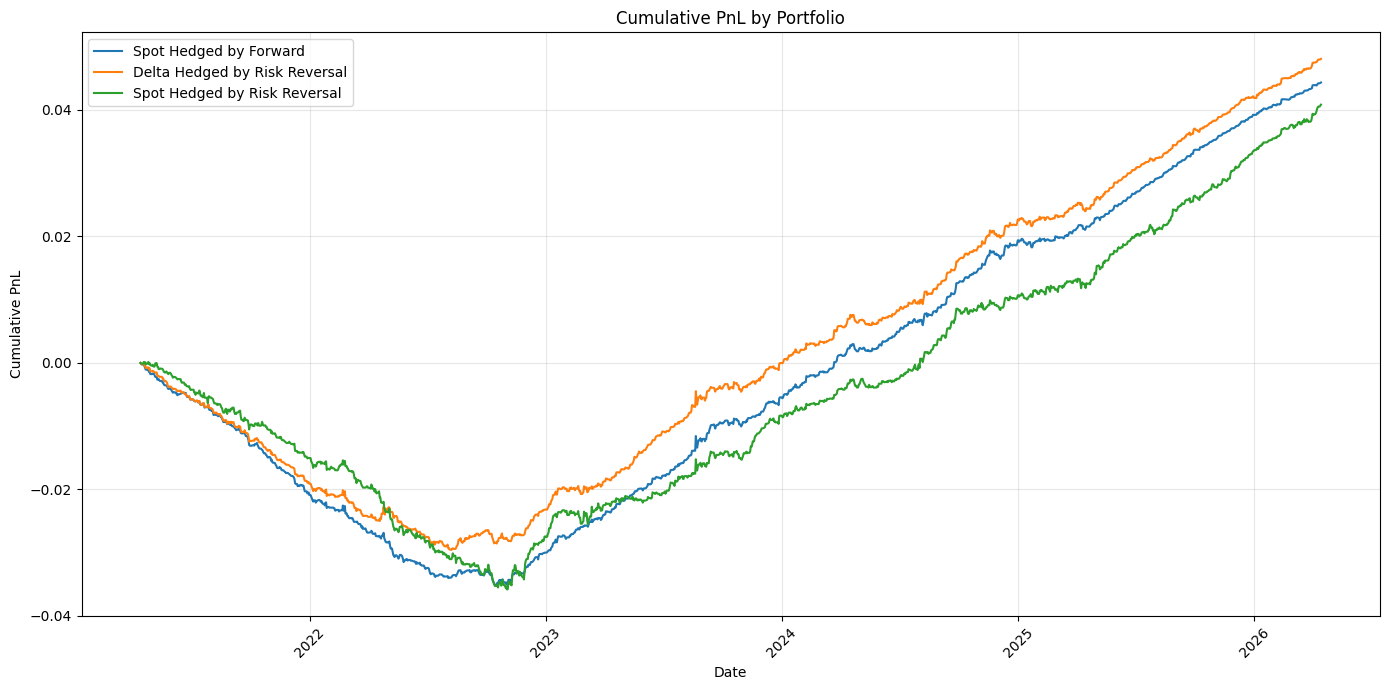

In [17]:
fig, ax = plt.subplots(figsize=(14, 7))

portfolios_to_plot = [
    (forward_spot_hedge_hedged_df,   'Spot Hedged by Forward'),
    (rr45_delta_hedge_hedged_df,     'Delta Hedged by Risk Reversal'),
    (rr45_spot_hedge_hedged_df,      'Spot Hedged by Risk Reversal'),
]

for df, label in portfolios_to_plot:
    ax.plot(df['Pricing_Date'], df['Portfolio_Cumulative_PnL'], label=label)

ax.set_title('Cumulative PnL by Portfolio')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative PnL')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

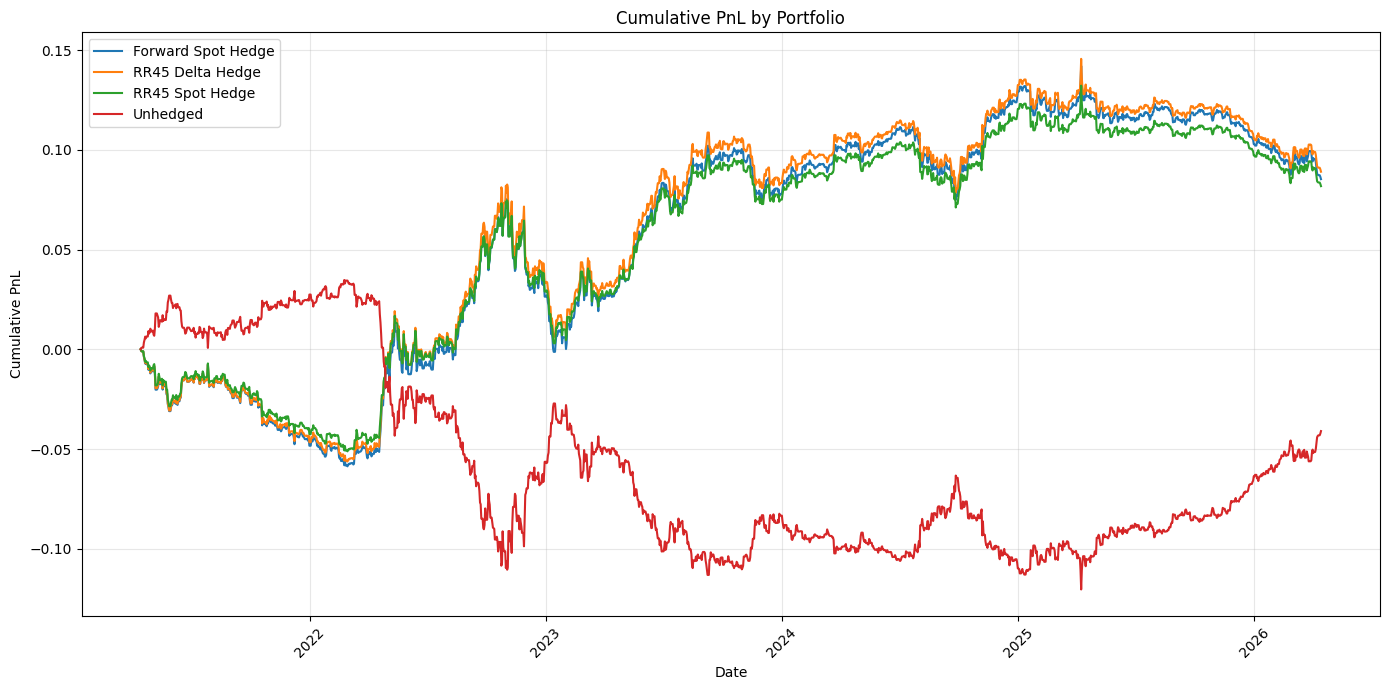

In [18]:
fig, ax = plt.subplots(figsize=(14, 7))

portfolios_to_plot = [
    (forward_spot_hedge_complete_pnl_df,   'Forward Spot Hedge'),
    (rr45_delta_hedge_complete_pnl_df,     'RR45 Delta Hedge'),
    (rr45_spot_hedge_complete_pnl_df,      'RR45 Spot Hedge'),
    (unhedged_complete_pnl_df,              'Unhedged'),
]

for df, label in portfolios_to_plot:
    ax.plot(df['Pricing_Date'], df['Portfolio_Cumulative_PnL'], label=label)

ax.set_title('Cumulative PnL by Portfolio')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative PnL')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Debugging

Same dates?

In [19]:
date_sets = {
    'Forward Unit Fixed':   set(forward_unit_fixed_complete_pnl_df['Pricing_Date']),
    'Forward Spot Hedge':   set(forward_spot_hedge_complete_pnl_df['Pricing_Date']),
    'RR45 Delta Hedge':     set(rr45_delta_hedge_complete_pnl_df['Pricing_Date']),
    'RR45 Spot Hedge':      set(rr45_spot_hedge_complete_pnl_df['Pricing_Date']),
    'RR45 Unit Fixed':      set(rr45_unit_fixed_complete_pnl_df['Pricing_Date']),
    'Unhedged':            set(unhedged_complete_pnl_df['Pricing_Date']),
}

reference_name, reference_dates = next(iter(date_sets.items()))
all_match = True

for name, dates in date_sets.items():
    if dates != reference_dates:
        all_match = False
        only_in_reference = reference_dates - dates
        only_in_current = dates - reference_dates
        print(f"MISMATCH: {name} vs {reference_name}")
        if only_in_reference:
            print(f"  Dates in {reference_name} but not {name}: {sorted(only_in_reference)}")
        if only_in_current:
            print(f"  Dates in {name} but not {reference_name}: {sorted(only_in_current)}")

if all_match:
    print("All dataframes have the same pricing dates.")

All dataframes have the same pricing dates.


Same notional / delta notional?

In [20]:
merged = forward_spot_hedge_realised_dates_df[['Pricing_Date', 'Portfolio_Notional']].merge(
    rr45_spot_hedge_realised_dates_df[['Pricing_Date', 'Portfolio_Notional']],
    on='Pricing_Date',
    how='outer',
    suffixes=('_forward_spot_hedge', '_rr45_spot_hedge')
).merge(
    rr45_delta_hedge_realised_dates_df[['Pricing_Date', 'Portfolio_Delta_Notional']],
    on='Pricing_Date',
    how='outer'
)

mismatches_forward_vs_delta = merged[
    (merged['Portfolio_Notional_forward_spot_hedge'] - merged['Portfolio_Delta_Notional']).abs() > 1e-6
]

mismatches_rr45_spot_vs_delta = merged[
    (merged['Portfolio_Notional_rr45_spot_hedge'] - merged['Portfolio_Delta_Notional']).abs() > 1e-6
]

if mismatches_forward_vs_delta.empty:
    print("Forward Spot Hedge Notional matches RR45 Delta Hedge Delta Notional on all dates.")
else:
    print(f"Forward Spot Hedge vs RR45 Delta Hedge — {len(mismatches_forward_vs_delta)} mismatches:")
    print(mismatches_forward_vs_delta)

print()

if mismatches_rr45_spot_vs_delta.empty:
    print("RR45 Spot Hedge Notional matches RR45 Delta Hedge Delta Notional on all dates.")
else:
    print(f"RR45 Spot Hedge vs RR45 Delta Hedge — {len(mismatches_rr45_spot_vs_delta)} mismatches:")
    print(mismatches_rr45_spot_vs_delta)

Forward Spot Hedge Notional matches RR45 Delta Hedge Delta Notional on all dates.

RR45 Spot Hedge Notional matches RR45 Delta Hedge Delta Notional on all dates.


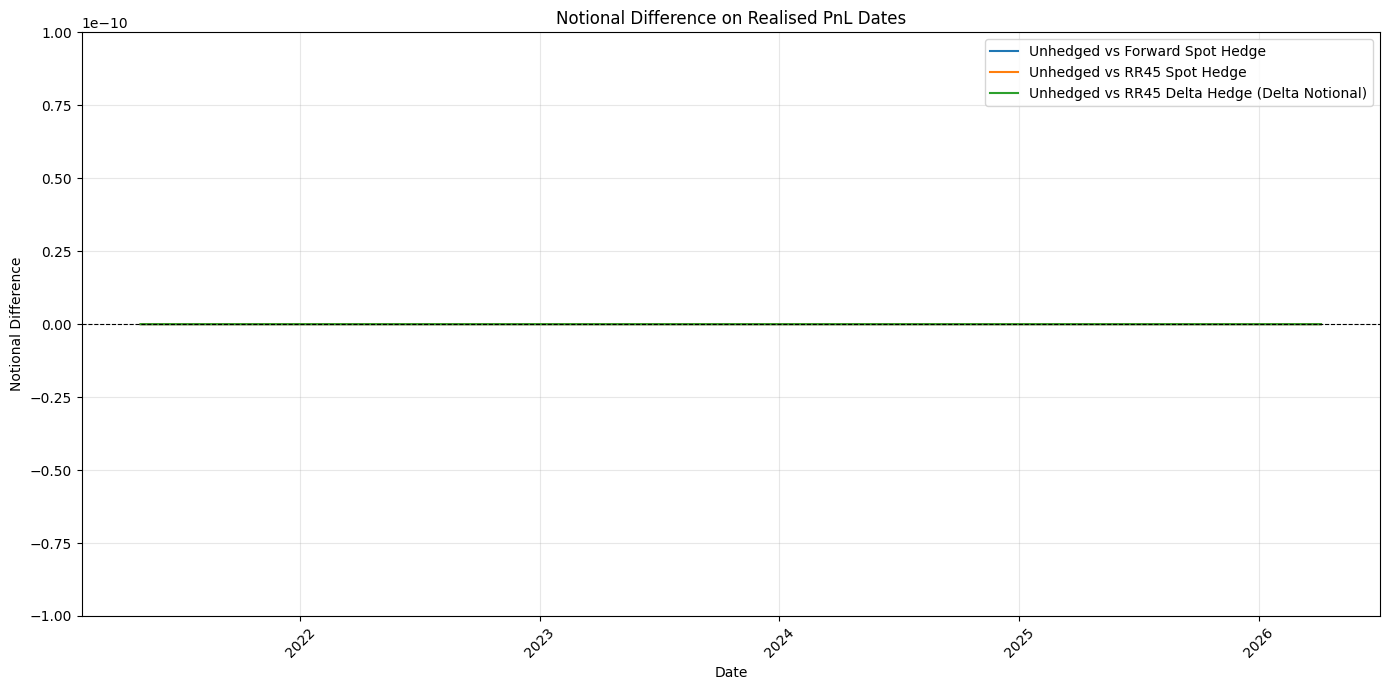

In [21]:
fig, ax = plt.subplots(figsize=(14, 7))

merged = unhedged_complete_pnl_df[['Pricing_Date', 'Portfolio_Notional']].merge(
    forward_spot_hedge_complete_pnl_df[['Pricing_Date', 'Portfolio_Notional', 'Portfolio_Realised_PnL']],
    on='Pricing_Date', how='inner', suffixes=('_unhedged', '_forward_spot')
).merge(
    rr45_spot_hedge_complete_pnl_df[['Pricing_Date', 'Portfolio_Notional', 'Portfolio_Realised_PnL']],
    on='Pricing_Date', how='inner'
).merge(
    rr45_delta_hedge_complete_pnl_df[['Pricing_Date', 'Portfolio_Delta_Notional', 'Portfolio_Realised_PnL']],
    on='Pricing_Date', how='inner'
).rename(columns={
    'Portfolio_Notional':       'Portfolio_Notional_rr45_spot',
    'Portfolio_Realised_PnL_x': 'Portfolio_Realised_PnL_forward_spot',
    'Portfolio_Realised_PnL_y': 'Portfolio_Realised_PnL_rr45_spot',
    'Portfolio_Realised_PnL':   'Portfolio_Realised_PnL_rr45_delta',
})

# filter to dates where any realised pnl is not 0
realised_mask = (
    (merged['Portfolio_Realised_PnL_forward_spot'].abs() > 1e-6) |
    (merged['Portfolio_Realised_PnL_rr45_spot'].abs() > 1e-6) |
    (merged['Portfolio_Realised_PnL_rr45_delta'].abs() > 1e-6)
)
merged = merged[realised_mask]

ax.plot(merged['Pricing_Date'], merged['Portfolio_Notional_unhedged'] - merged['Portfolio_Notional_forward_spot'], label='Unhedged vs Forward Spot Hedge')
ax.plot(merged['Pricing_Date'], merged['Portfolio_Notional_unhedged'] - merged['Portfolio_Notional_rr45_spot'],   label='Unhedged vs RR45 Spot Hedge')
ax.plot(merged['Pricing_Date'], merged['Portfolio_Notional_unhedged'] - merged['Portfolio_Delta_Notional'],       label='Unhedged vs RR45 Delta Hedge (Delta Notional)')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Notional Difference on Realised PnL Dates')
ax.set_xlabel('Date')
ax.set_ylabel('Notional Difference')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
ax.set_ylim(-0.0000000001, 0.0000000001)
plt.tight_layout()
plt.show()

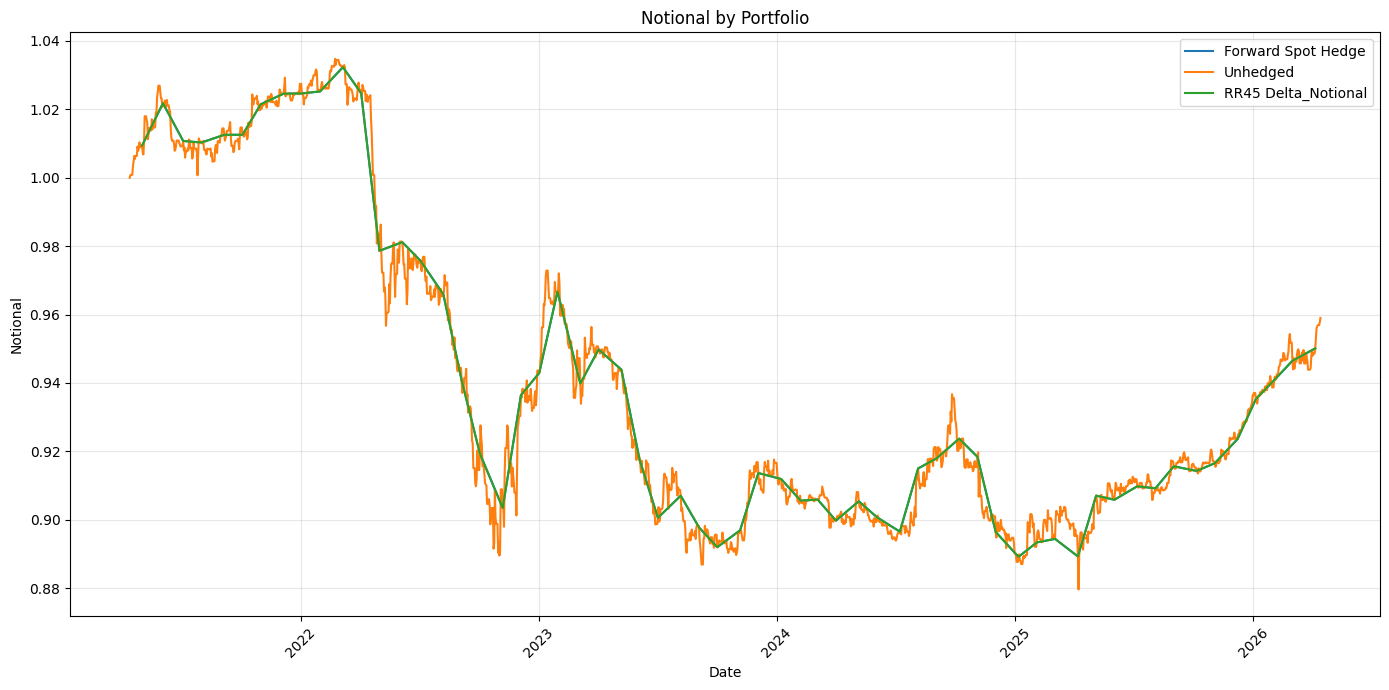

In [22]:
fig, ax = plt.subplots(figsize=(14, 7))

portfolios_to_plot = [
    (forward_spot_hedge_realised_dates_df,   'Forward Spot Hedge'),
    # (rr45_delta_hedge_realised_dates_df,     'RR45 Delta Hedge'),
    # (rr45_spot_hedge_realised_dates_df,      'RR45 Spot Hedge'),
    (unhedged_complete_pnl_df,              'Unhedged'),
]

for df, label in portfolios_to_plot:
    ax.plot(df['Pricing_Date'], df['Portfolio_Notional'], label=label)

ax.plot(rr45_delta_hedge_realised_dates_df['Pricing_Date'], rr45_delta_hedge_realised_dates_df['Portfolio_Delta_Notional'], label='RR45 Delta_Notional')

ax.set_title('Notional by Portfolio')
ax.set_xlabel('Date')
ax.set_ylabel('Notional')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()